In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_auc_score, roc_curve
)

In [3]:
df = pd.read_csv("/content/churn.csv")

In [4]:
df.shape

(7043, 21)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [13]:
df["Contract"]


,Contract
0,Month-to-month
1,One year
2,Month-to-month
3,One year
4,Month-to-month
...,...
7038,One year
7039,One year
7040,Month-to-month
7041,Month-to-month


In [6]:
df.describe(include='all').T


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
customerID,7043,7043,3186-AJIEK,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
gender,7043,2,Male,3555,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SeniorCitizen,7043.0,NaN,NaN,NaN,0.162147,0.368612,0.0,0.0,0.0,0.0,1.0
Partner,7043,2,No,3641,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Dependents,7043,2,No,4933,NaN,NaN,NaN,NaN,NaN,NaN,NaN
tenure,7043.0,NaN,NaN,NaN,32.371149,24.559481,0.0,9.0,29.0,55.0,72.0
PhoneService,7043,2,Yes,6361,NaN,NaN,NaN,NaN,NaN,NaN,NaN
MultipleLines,7043,3,No,3390,NaN,NaN,NaN,NaN,NaN,NaN,NaN
InternetService,7043,3,Fiber optic,3096,NaN,NaN,NaN,NaN,NaN,NaN,NaN
OnlineSecurity,7043,3,No,3498,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [7]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


Churn
No     5174
Yes    1869
Name: count, dtype: int64
Churn
No     73.46
Yes    26.54
Name: proportion, dtype: float64


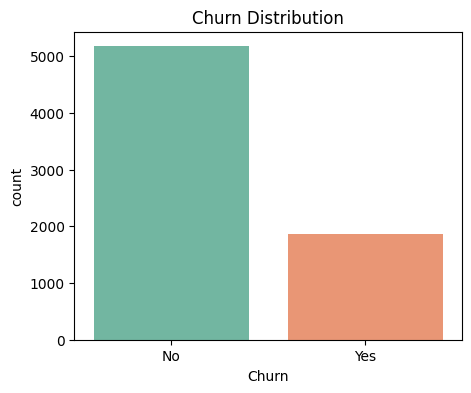

In [8]:
# Target class balance
churn_counts = df['Churn'].value_counts()
churn_pct = df['Churn'].value_counts(normalize=True) * 100
print(churn_counts)
print(churn_pct.round(2))

plt.figure(figsize=(5, 4))
sns.countplot(data=df, x='Churn', hue='Churn', palette='Set2', legend=False)
plt.title('Churn Distribution')
plt.show()


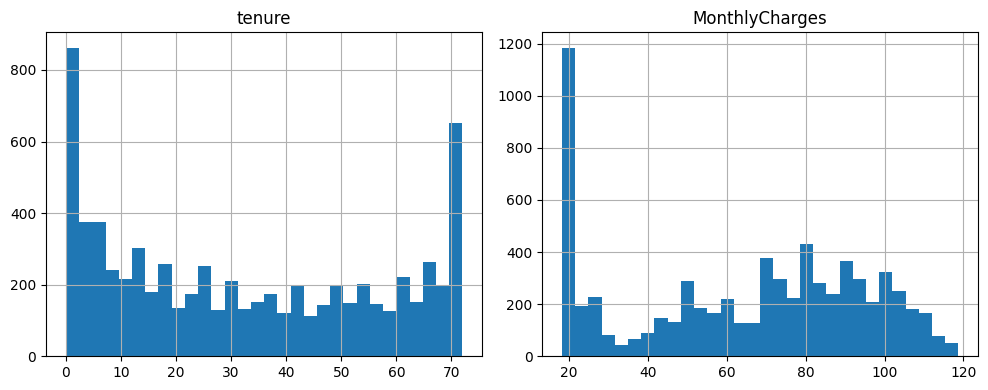

In [9]:
numeric_cols = ['tenure', 'MonthlyCharges']
df[numeric_cols].hist(bins=30, figsize=(10, 4))
plt.tight_layout()
plt.show()

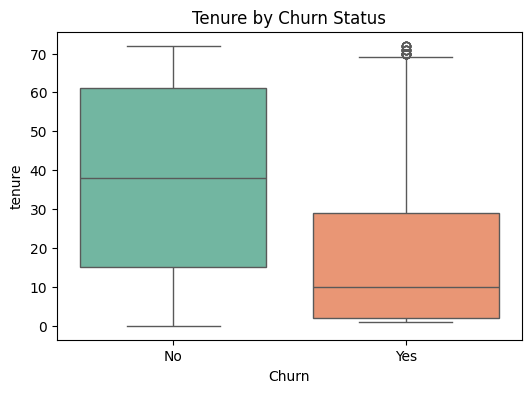

In [10]:
plt.figure(figsize=(6, 4))
sns.boxplot(data=df, x='Churn', y='tenure', hue='Churn', palette='Set2', legend=False)
plt.title('Tenure by Churn Status')
plt.show()

In [14]:
df["TotalCharges"].apply(type).value_counts()

,count
TotalCharges,
<class 'str'>,7043


In [16]:
mask_bad = pd.to_numeric(df["TotalCharges"], errors = "coerce").isna()

In [17]:
df.loc[mask_bad, ["customerID","tenure","TotalCharges"]]

,customerID,tenure,TotalCharges
488,4472-LVYGI,0,
753,3115-CZMZD,0,
936,5709-LVOEQ,0,
1082,4367-NUYAO,0,
1340,1371-DWPAZ,0,
3331,7644-OMVMY,0,
3826,3213-VVOLG,0,
4380,2520-SGTTA,0,
5218,2923-ARZLG,0,
6670,4075-WKNIU,0,


In [18]:
df_clean = df.copy()
df_clean["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors = "coerce")

In [19]:
df_clean["TotalCharges"] = df_clean["TotalCharges"].fillna(0)

In [ ]:
df_clean = df_clean.drop(columns=['customerID'])


In [ ]:
df_clean.duplicated().sum()

In [ ]:
df_clean = df_clean.drop_duplicates()

In [ ]:
df_clean['Churn'] = df_clean['Churn'].map({'No': 0, 'Yes': 1})

target_col = 'Churn'
numeric_features = ['tenure', 'MonthlyCharges', 'TotalCharges']
categorical_features = [
    c for c in df_clean.columns if c not in numeric_features + [target_col]
]



# for c in df_clean.columns:
#   if c not in numeric_features and target_col:
#     categorical_feature.append(c)

print("Numeric features:", numeric_features)
print("Categorical features:", categorical_features)


In [ ]:
df_encoded = pd.get_dummies(df_clean, columns=categorical_features, drop_first=True)

print(f"Shape after one-hot encoding: {df_encoded.shape}")
df_encoded.head()


In [ ]:
X = df_encoded.drop(columns=[target_col]).astype(float)
y = df_encoded[target_col].astype(float)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)